In [133]:
import pandas as pd

In [134]:
import os
from pathlib import Path
# Force working directory to the notebook's own folder
NOTEBOOK_DIR = Path().resolve()
os.chdir(NOTEBOOK_DIR)
DATA_DIR = NOTEBOOK_DIR / "data"

In [135]:
career_info = pd.read_csv(DATA_DIR / "Player Career Info.csv")
career_info.head()

,player,player_id,pos,ht_in_in,wt,birth_date,colleges,from,to,debut,hof
0,Hank Biasatti,biasaha01,G,71.0,175.0,1922-01-14,Assumption University,1947,1947,1946-11-01T00:00:00Z,False
1,Tommy Byrnes,byrneto01,F-G,75.0,175.0,1923-02-19,Seton Hall,1947,1951,1946-11-01T00:00:00Z,False
2,Bob Fitzgerald,fitzgbo01,F-C,77.0,190.0,1923-03-14,Seton Hall,1947,1949,1946-11-01T00:00:00Z,False
3,Dick Fitzgerald,fitzgdi01,F,74.0,175.0,1920-11-18,Fordham,1947,1948,1946-11-01T00:00:00Z,False
4,Frank Fucarino,fucarfr01,F,74.0,175.0,1920-07-24,Long Island University,1947,1947,1946-11-01T00:00:00Z,False


In [136]:
#calculate players career length
career_info_length = career_info[["player_id", "player", "pos", "ht_in_in", "wt", "from", "to", "hof"]].copy()
career_info_length["career_length"] = career_info_length["to"] - career_info_length["from"] + 1

career_info_length.head()

,player_id,player,pos,ht_in_in,wt,from,to,hof,career_length
0,biasaha01,Hank Biasatti,G,71.0,175.0,1947,1947,False,1
1,byrneto01,Tommy Byrnes,F-G,75.0,175.0,1947,1951,False,5
2,fitzgbo01,Bob Fitzgerald,F-C,77.0,190.0,1947,1949,False,3
3,fitzgdi01,Dick Fitzgerald,F,74.0,175.0,1947,1948,False,2
4,fucarfr01,Frank Fucarino,F,74.0,175.0,1947,1947,False,1


In [137]:
totals = pd.read_csv(DATA_DIR / "Player Totals.csv")
totals.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,orb,drb,trb,ast,stl,blk,tov,pf,pts,trp_dbl
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,73,57.0,1745.0,...,177.0,315.0,492.0,101,65.0,50.0,65.0,123.0,736,0.0
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,730.0,...,145.0,131.0,276.0,48,22.0,20.0,35.0,55.0,187,0.0
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,2365.0,...,149.0,583.0,732.0,232,86.0,49.0,120.0,122.0,1468,0.0
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,62,13.0,973.0,...,46.0,95.0,141.0,47,24.0,17.0,31.0,93.0,314,0.0
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,650.0,...,33.0,62.0,95.0,30,17.0,11.0,19.0,75.0,181,0.0


In [138]:
stats_cols = ["g", "gs", "mp", "fg", "fga", "x3p", "x3pa", "x2p", "x2pa",
            "ft", "fta", "orb", "drb", "trb", "ast", "stl", "blk", "tov",
            "pf", "pts", "trp_dbl"]

# sum columns to find career totals then change the column name to align
totals_career = totals.groupby("player_id")[stats_cols].sum().add_prefix("career_").reset_index()

# rename player_id column because we just changed all columns to start with career_
totals_career = totals_career.rename(columns={"career_player_id": "player_id"})

totals_career.head()

,player_id,career_g,career_gs,career_mp,career_fg,career_fga,career_x3p,career_x3pa,career_x2p,career_x2pa,...,career_orb,career_drb,career_trb,career_ast,career_stl,career_blk,career_tov,career_pf,career_pts,career_trp_dbl
0,abdelal01,385,105.0,5017.0,983,1940,0.0,6.0,983.0,1934.0,...,446.0,851.0,1297.0,125,111.0,107.0,389.0,777.0,2299,0.0
1,abdulka01,1560,789.0,57446.0,15837,28307,1.0,18.0,6692.0,11689.0,...,2975.0,9394.0,17440.0,5660,1160.0,3189.0,2527.0,4657.0,38387,21.0
2,abdulma01,779,0.0,19965.0,3704,8418,0.0,0.0,0.0,0.0,...,18.0,39.0,2234.0,3684,26.0,6.0,0.0,2137.0,9348,1.0
3,abdulma02,586,336.0,15628.0,3514,7943,474.0,1339.0,3040.0,6604.0,...,219.0,868.0,1087.0,2079,487.0,46.0,963.0,1106.0,8553,0.0
4,abdulta01,321,213.0,6826.0,1049,2519,22.0,101.0,1027.0,2418.0,...,428.0,723.0,1151.0,388,263.0,121.0,442.0,688.0,2662,0.0


In [139]:
totals_career["career_fg_pct"] = totals_career["career_fg"] / totals_career["career_fga"]
totals_career["career_x3p_pct"] = totals_career["career_x3p"] / totals_career["career_x3pa"]
totals_career["career_ft_pct"] = totals_career["career_ft"] / totals_career["career_fta"]
totals_career["career_pts_per_g"] = totals_career["career_pts"] / totals_career["career_g"]
totals_career["career_ast_per_g"] = totals_career["career_ast"] / totals_career["career_g"]
totals_career["career_trb_per_g"] = totals_career["career_trb"] / totals_career["career_g"]

totals_career.head()

,player_id,career_g,career_gs,career_mp,career_fg,career_fga,career_x3p,career_x3pa,career_x2p,career_x2pa,...,career_tov,career_pf,career_pts,career_trp_dbl,career_fg_pct,career_x3p_pct,career_ft_pct,career_pts_per_g,career_ast_per_g,career_trb_per_g
0,abdelal01,385,105.0,5017.0,983,1940,0.0,6.0,983.0,1934.0,...,389.0,777.0,2299,0.0,0.506701,0.000000,0.705508,5.971429,0.324675,3.368831
1,abdulka01,1560,789.0,57446.0,15837,28307,1.0,18.0,6692.0,11689.0,...,2527.0,4657.0,38387,21.0,0.559473,0.055556,0.721410,24.607051,3.628205,11.179487
2,abdulma01,779,0.0,19965.0,3704,8418,0.0,0.0,0.0,0.0,...,0.0,2137.0,9348,1.0,0.440010,NaN,0.758109,12.000000,4.729140,2.867779
3,abdulma02,586,336.0,15628.0,3514,7943,474.0,1339.0,3040.0,6604.0,...,963.0,1106.0,8553,0.0,0.442402,0.353996,0.905254,14.595563,3.547782,1.854949
4,abdulta01,321,213.0,6826.0,1049,2519,22.0,101.0,1027.0,2418.0,...,442.0,688.0,2662,0.0,0.416435,0.217822,0.717881,8.292835,1.208723,3.585670


In [140]:
advanced = pd.read_csv(DATA_DIR / "Advanced.csv")
advanced.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,73,57.0,1745.0,...,9.0,17.6,1.8,1.2,2.9,0.081,-0.5,-1.1,-1.6,0.2
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,730.0,...,16.7,12.1,1.1,1.0,2.1,0.141,-0.1,-0.3,-0.5,0.3
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,2365.0,...,8.3,25.0,2.8,3.6,6.4,0.129,1.5,0.4,2.0,2.4
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,62,13.0,973.0,...,9.4,14.6,0.1,0.8,0.9,0.046,-3.5,-0.5,-4.0,-0.5
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,650.0,...,9.4,13.3,0.0,0.7,0.6,0.048,-4.8,0.1,-4.7,-0.5


In [141]:
# advanced_efficiency_cols cant be added together like the advanced_summation_cols can
advanced_summation_cols = ["ows", "dws", "ws", "vorp"]
advanced_efficiency_cols = ["per", "ts_percent", "bpm", "obpm", "dbpm", "usg_percent"]

# career sums for the stats that are cumulative/ the ones we can just add together
advanced_sums = advanced.groupby("player_id")[advanced_summation_cols].sum().add_prefix("career_").reset_index()
advanced_sums = advanced_sums.rename(columns={"career_player_id": "player_id"})

# multiply the rate/efficiency percentage columns by minutes
advanced_w = advanced.dropna(subset=["mp"]).copy()
weighted_stats = advanced_w[advanced_efficiency_cols].mul(advanced_w["mp"], axis=0)

# add player_id and minutes played back to the dataset and then find the sum
weighted_stats[["player_id", "mp"]] = advanced_w[["player_id", "mp"]]
grouped = weighted_stats.groupby("player_id").sum()

# divide the sum of the weighted stats that we calculated by the total minutes
advanced_weighted = (grouped[advanced_efficiency_cols].div(grouped["mp"], axis=0).add_prefix("career_avg_").reset_index())

# identify players' best season through win share/player impact
peak = advanced.groupby("player_id")["ws"].max().reset_index().rename(columns={"ws": "peak_season_ws"})

advanced_sums.head()

,player_id,career_ows,career_dws,career_ws,career_vorp
0,abdelal01,1.0,6.2,7.1,-2.4
1,abdulka01,179.0,94.5,273.3,85.9
2,abdulma01,18.4,12.9,31.2,0.0
3,abdulma02,16.9,8.4,25.1,4.6
4,abdulta01,-0.6,6.2,5.5,-1.1


In [142]:
# only need number of seasons because we can join the data later to then compare with other columns
# lots of repetitive columns in this set since if a player played 10 seasons they have 10 rows and we already have career stats
season_info = pd.read_csv(DATA_DIR / "Player Season Info.csv")
seasons_played = season_info.groupby("player_id")["season"].nunique().reset_index()
seasons_played = seasons_played.rename(columns={"season": "n_seasons"})

seasons_played.head()

,player_id,n_seasons
0,abdelal01,5
1,abdulka01,20
2,abdulma01,10
3,abdulma02,9
4,abdulta01,6


In [143]:
# checking all star status and counting number of times
all_star = pd.read_csv(DATA_DIR / "All-Star Selections.csv")
all_star_count = all_star.groupby("player_id").size().reset_index(name="n_all_star")

end_of_season = pd.read_csv(DATA_DIR / "End of Season Teams.csv")

# sum awards
all_nba = end_of_season[end_of_season["type"] == "All-NBA"].groupby("player_id").size().reset_index(name="n_all_nba")
all_def = end_of_season[end_of_season["type"] == "All-Defense"].groupby("player_id").size().reset_index(name="n_all_defense")
all_rookie = end_of_season[end_of_season["type"] == "All-Rookie"].groupby("player_id").size().reset_index(name="n_all_rookie")

# finds All-NBA AND 1st team 
first_team_all_nba = end_of_season[(end_of_season["type"] == "All-NBA") & (end_of_season["number_tm"] == "1st")]
first_team_count = first_team_all_nba.groupby("player_id").size().reset_index(name="n_first_team_all_nba")

# sum awards and award share
awards = pd.read_csv(DATA_DIR / "Player Award Shares.csv")
award_sum = awards.groupby("player_id").agg(max_award_share=("share", "max"), total_award_share=("share", "sum"), n_award_wins=("winner", "sum"),).reset_index()

# keep all awards with MVP in the name, not case sensitive
# ~awards flips the entire column of true/false values similar to NOT but for an entire column of values
mvp = awards[awards["award"].str.contains("mvp", case = False, na = False) & ~awards["award"].str.contains("clutch|def|roy|6th|sixth", case=False, na=False)]

mvp_sum = mvp.groupby("player_id").agg(mvp_max_share=("share", "max"),n_mvp_wins=("winner", "sum"),).reset_index()

all_star_count.head()

,player_id,n_all_star
0,abdulka01,19
1,abdulma01,1
2,abdursh01,1
3,adamsal01,1
4,adamsmi01,1


In [144]:
# Now, we can finally combine all the data into one dataset

NBA_data = career_info_length.merge(totals_career, on="player_id", how="left")
NBA_data = NBA_data.merge(advanced_sums, on="player_id", how="left")
NBA_data = NBA_data.merge(advanced_weighted, on="player_id", how="left")
NBA_data = NBA_data.merge(peak, on="player_id", how="left")
NBA_data = NBA_data.merge(seasons_played, on="player_id", how="left")
NBA_data = NBA_data.merge(all_star_count, on="player_id", how="left")
NBA_data = NBA_data.merge(all_nba, on="player_id", how="left")
NBA_data = NBA_data.merge(all_def, on="player_id", how="left")
NBA_data = NBA_data.merge(all_rookie, on="player_id", how="left")
NBA_data = NBA_data.merge(first_team_count, on="player_id", how="left")
NBA_data = NBA_data.merge(award_sum, on="player_id", how="left")
NBA_data = NBA_data.merge(mvp_sum, on="player_id", how="left")

NBA_data.head()

,player_id,player,pos,ht_in_in,wt,from,to,hof,career_length,career_g,...,n_all_star,n_all_nba,n_all_defense,n_all_rookie,n_first_team_all_nba,max_award_share,total_award_share,n_award_wins,mvp_max_share,n_mvp_wins
0,biasaha01,Hank Biasatti,G,71.0,175.0,1947,1947,False,1,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,byrneto01,Tommy Byrnes,F-G,75.0,175.0,1947,1951,False,5,368,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fitzgbo01,Bob Fitzgerald,F-C,77.0,190.0,1947,1949,False,3,138,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fitzgdi01,Dick Fitzgerald,F,74.0,175.0,1947,1948,False,2,61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fucarfr01,Frank Fucarino,F,74.0,175.0,1947,1947,False,1,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
# for players that didnt win an award or appear in All-Star selection, we want to just put in 0 for the missing value
missing_cols = ["n_all_star", "n_all_nba", "n_all_defense", "n_all_rookie", "n_first_team_all_nba", "n_award_wins", "n_mvp_wins", "max_award_share", "total_award_share", "mvp_max_share", "career_x3p_pct"]
NBA_data[missing_cols] = NBA_data[missing_cols].fillna(0)

# drop any player with no career stats
NBA_data = NBA_data.dropna(subset = ["career_g"])
NBA_data["hof"] = NBA_data["hof"].astype(int)
# NBA_data["true_shooting"] = NBA_data["career_pts"] / (2* NBA_data["career_fga"] + 0.44 * NBA_data["career_fta"])

NBA_data.shape

(5416, 58)

In [146]:
NBA_data = NBA_data.fillna(0)
NBA_data.head()

,player_id,player,pos,ht_in_in,wt,from,to,hof,career_length,career_g,...,n_all_star,n_all_nba,n_all_defense,n_all_rookie,n_first_team_all_nba,max_award_share,total_award_share,n_award_wins,mvp_max_share,n_mvp_wins
0,biasaha01,Hank Biasatti,G,71.0,175.0,1947,1947,0,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,byrneto01,Tommy Byrnes,F-G,75.0,175.0,1947,1951,0,5,368,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,fitzgbo01,Bob Fitzgerald,F-C,77.0,190.0,1947,1949,0,3,138,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,fitzgdi01,Dick Fitzgerald,F,74.0,175.0,1947,1948,0,2,61,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,fucarfr01,Frank Fucarino,F,74.0,175.0,1947,1947,0,1,28,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X = NBA_data.drop(columns=[
    "hof", "player_id", "player", "pos", "career_avg_per", "career_avg_ts_percent",
    "career_avg_bpm", "career_avg_obpm", "career_avg_dbpm", "career_avg_usg_percent", "to", "from"
    # "career_x3p", "career_x3pa", "career_x2p", "career_x2pa", "career_fta", "career_ft"
])
y = NBA_data["hof"].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=111,
    stratify=y
)

model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

clf = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", model)
])

clf.fit(X_train, y_train)

perm = permutation_importance(
    clf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=111,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(importance_df.head(15))

             feature  importance_mean  importance_std
33       career_vorp         0.164723        0.015877
35         n_seasons         0.094196        0.017695
21         career_pf         0.072523        0.014798
13        career_fta         0.028465        0.008421
9        career_x3pa         0.019658        0.011550
44     mvp_max_share         0.016096        0.002952
31        career_dws         0.014943        0.006256
2      career_length         0.013508        0.009931
28  career_ast_per_g         0.012363        0.007886
37         n_all_nba         0.011907        0.003541
36        n_all_star         0.011363        0.003771
34    peak_season_ws         0.011341        0.005029
16        career_trb         0.010722        0.012694
29  career_trb_per_g         0.010587        0.004784
3           career_g         0.010381        0.005924


In [148]:
important_selected_features = [
    "career_vorp",
    "n_seasons",
    "career_pf",        # high importance but not in selected_features originally
    "career_fta",       # same
    "career_x3pa",      # same
    "mvp_max_share",
    "career_dws",       # high importance but not in selected_features originally
    "career_length",
    "career_ast_per_g", # high importance but not in selected_features originally
    "n_all_nba",
    "n_all_star",
    "peak_season_ws",
    "career_trb",
    "career_trb_per_g", # high importance but not in selected_features originally
    "career_g"
]

In [149]:
#establish test train splits and remove any outliers
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

#restrict data set to players who are HOF eligible
eligible_df_full = NBA_data[NBA_data['to'] <= 2018].copy().reset_index(drop=True)
eligible_df = eligible_df[important_selected_features]
eligible_df['hof'] = eligible_df_full['hof']
eligible_df.head()

#Set X and y
X = eligible_df.drop(columns=["hof"])
y = eligible_df["hof"].values

#train test split for cross validation for model selection
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=111,
    stratify=y
)

#validation split for parameter tuning
X_tune, X_val, y_tune, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=111,
    stratify=y_train
)

train_df = X_train.copy()
train_df['hof'] = y_train
tune_df = X_tune.copy()
tune_df['hof'] = y_tune


def inlierer(df): #Returns X and y from df with only points considered inliers
    #Scale df(scalee) for outlier detecion and modeling
    scalee = df.drop('hof', axis=1)
    scaler = StandardScaler().set_output(transform='pandas').fit(scalee)
    scalee = scaler.transform(scalee)
    scalee['hof'] = df['hof']
    #compute outliers
    outlier_detector = LocalOutlierFactor(n_neighbors=20)
    outliers = outlier_detector.fit_predict(scalee)
    od = df.copy()
    od['anomaly'] = outliers
    normal_points = od[od['anomaly'] == 1]
    anomalies = len(df)-len(normal_points)
    #select inliers
    X_inliers = normal_points.drop(['hof', 'anomaly'],axis=1)
    y_inliers = normal_points['hof'].values
    print(f'Removed {anomalies} outliers')
    return X_inliers, y_inliers

J_X_train_inliers, J_y_train_inliers = inlierer(train_df)
J_X_tune_inliers, J_y_tune_inliers = inlierer(tune_df)

Removed 84 outliers
Removed 75 outliers


In [150]:
print(len(train_df),len(tune_df))

3310 2648


In [157]:
#intitialize models and parameter arrays for GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

radialSVC_params = {
    'C': [0.1, 0.5, 1, 2, 8, 16, 32, 64],
    'gamma': ['scale', 'auto', 0.5, 1, 2, 8, 32, 64],
    'kernel': ['rbf'],
    'random_state': [111]
}

knn_params = {
    'n_neighbors' : [2, 8, 16, 32, 64],
    'weights' : ['uniform', 'distance']
}

rf_params = {
    'n_estimators' : [1, 10, 100, 512, 10000],
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_depth' : [2, 5, 8, 16, None],
    'random_state' : [111]
}

j_models = {
    'radialSVC' : {'model' : SVC, 'params' : radialSVC_params},
    'knn' : {'model' : KNeighborsClassifier, 'params' : knn_params},
    'rf' : {'model' : RandomForestClassifier, 'params' : rf_params}
}

In [160]:
#find best params for each model
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import numpy as np

tuning_results = {
    'radialSVC': {
        'best params': {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf', 'random_state': 111},
        'best score': 0.986673386612907
    }, 
    'knn': {
        'best params': {'n_neighbors': 16, 'weights': 'distance'}, 
        'best score':0.9838836489308086
    }, 
    'rf': {
        'best params': {
            'criterion': 'entropy', 'max_depth': None, 'n_estimators': 10, 'random_state': 111
        }, 
        'best score': np.float64(0.9844479004665629)
    }
}

"""
#Commenting out computationally expensive GridSearchCV. 
tuning_results = {}
#Best paramaters for each model found in the proceeding cell
for model_name, o in j_models.items():
    model = o['model']
    param_grid = o['params']
    clf = GridSearchCV(model(), param_grid, n_jobs=-1)
    scaler = StandardScaler()
    pipe = Pipeline([
        ('scaler', scaler),
        ('clf', clf)
    ])
    pipe.fit(J_X_train_inliers, J_y_train_inliers)
    m = pipe.named_steps['clf']
    results = {
        'best params': m.best_params_,
        'best score' : m.best_score_
    }
    tuning_results[model_name] = results
    print(model_name)
"""

for model_name in tuning_results:
    print(model_name)
    print('Best paramaters: ', tuning_results[model_name]['best params'])
    print('Best score: ', tuning_results[model_name]['best score'])
    print()
    

radialSVC
Best paramaters:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf', 'random_state': 111}
Best score:  0.986673386612907

knn
Best paramaters:  {'n_neighbors': 16, 'weights': 'distance'}
Best score:  0.9838836489308086

rf
Best paramaters:  {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 10, 'random_state': 111}
Best score:  0.9844479004665629



In [161]:
best_radialSVC = SVC(C=0.5, gamma='scale', kernel='rbf', probability=True, random_state=111)
best_knn = KNeighborsClassifier(n_neighbors=16, weights='distance')
best_rf = RandomForestClassifier(n_estimators=10, criterion='entropy', max_depth=None, random_state=111)

In [173]:
from sklearn.metrics import roc_auc_score

# fit models

j_best_models = {
    'radialSVC' : best_radialSVC, 
    'knn' : best_knn,
    'Random Forest' : best_rf
}

pipe_make = lambda m: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', m)
    ])
results = []

for name, model in j_best_models.items():
    pipe_m = pipe_make(model)
    pipe_m.fit(J_X_train_inliers, J_y_train_inliers)
    pred = pipe_m.predict(X_test)
    prob = pipe_m.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, prob)
    results.append({"Name": name, "Score": auc})

results_df = pd.DataFrame(results)
results_df.head()

,Name,Score
0,radialSVC,0.931175
1,knn,0.956883
2,Random Forest,0.960976


In [174]:
from sklearn.model_selection import cross_val_score

cv_result = []

for name, model in j_best_models.items():
    pipe_m = pipe_make(model)
    scores = cross_val_score(pipe_m, J_X_train_inliers, J_y_train_inliers, cv=5, scoring="roc_auc")
    cv_result.append({"Name": name, "Average Score": scores.mean(), "Std Dev": scores.std()})

cv_results_df = pd.DataFrame(cv_result)
j_best_model = cv_results_df.sort_values(by='Average Score', ascending=False).iloc[0]['Name']
cv_results_df.head()

,Name,Average Score,Std Dev
0,radialSVC,0.902217,0.084023
1,knn,0.905514,0.034803
2,Random Forest,0.920931,0.061323


In [175]:
j_best_model

'Random Forest'

In [176]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tune_model = pipe_make(j_best_models[j_best_model])
tune_model.fit(J_X_tune_inliers, J_y_tune_inliers)
y_proba_val = tune_model.predict_proba(X_val)[:, 1]

# start, stop, num
thresholds = np.linspace(0.1, 0.9, 17)
rows = []

for t in thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    acc = accuracy_score(y_val, y_pred_t)
    prec = precision_score(y_val, y_pred_t) # how many are actually hof
    rec = recall_score(y_val, y_pred_t) # correctly flagged hof
    f1 = f1_score(y_val, y_pred_t) # balance between precision and f1
    rows.append({"threshold": t, "accuracy" : acc, "precision": prec, "recall": rec, "f1": f1})

threshold_df = pd.DataFrame(rows)
"""
#repeat above for smaller thresholds
# start, stop, num
thresholds = np.linspace(0, 0.15, 17)
rows = []

for t in thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    acc = accuracy_score(y_val, y_pred_t)
    prec = precision_score(y_val, y_pred_t) # how many are actually hof
    rec = recall_score(y_val, y_pred_t) # correctly flagged hof
    f1 = f1_score(y_val, y_pred_t) # balance between precision and f1
    rows.append({"threshold": t, "accuracy" : acc, "precision": prec, "recall": rec, "f1": f1})

small_threshold_df = pd.DataFrame(rows)
thresholds = pd.concat([threshold_df, small_threshold_df])
"""

threshold_df

,threshold,accuracy,precision,recall,f1
0,0.10,0.927492,0.333333,0.777778,0.466667
1,0.15,0.963746,0.545455,0.666667,0.600000
2,0.20,0.963746,0.545455,0.666667,0.600000
3,0.25,0.977341,0.750000,0.666667,0.705882
4,0.30,0.978852,0.809524,0.629630,0.708333
5,0.35,0.978852,0.809524,0.629630,0.708333
6,0.40,0.978852,0.809524,0.629630,0.708333
7,0.45,0.981873,0.894737,0.629630,0.739130
8,0.50,0.981873,0.894737,0.629630,0.739130
9,0.55,0.977341,0.928571,0.481481,0.634146


In [177]:
best_threshold = threshold_df[threshold_df["f1"] == threshold_df["f1"].max()]["threshold"].iloc[0]
# Nash
tune_model.predict_proba(X.iloc[[2980]])[:,1][0] >= best_threshold

np.True_

In [178]:
best_threshold

np.float64(0.45000000000000007)

In [179]:
from sklearn.model_selection import FixedThresholdClassifier
tuned_model = FixedThresholdClassifier(tune_model, threshold=best_threshold)
tuned_model.fit(J_X_train_inliers, J_y_train_inliers)

,"estimator estimator: estimator instanceThe binary classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step..._state=111))])
,"threshold threshold: {""auto""} or float, default=""auto""The decision threshold to use when converting posterior probability estimates(i.e. output of `predict_proba`) or decision scores (i.e. output of`decision_function`) into a class label. When `""auto""`, the threshold is setto 0.5 if `predict_proba` is used as `response_method`, otherwise it is set to0 (i.e. the default threshold for `decision_function`).",np.float64(0....0000000000007)
,"pos_label pos_label: int, float, bool or str, default=NoneThe label of the positive class. Used to process the output of the`response_method` method. When `pos_label=None`, if `y_true` is in `{-1, 1}` or`{0, 1}`, `pos_label` is set to 1, otherwise an error will be raised.",None
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [180]:
tuned_model.score(X_test, y_test)

0.9806763285024155

In [191]:
predict_set = NBA_data[important_selected_features]

def pred_hof(player, model=tuned_model):
    row = NBA_data[NBA_data['player'] == player]
    try:
        assert len(row)
    except:
        print(f'{player} not found in Data Set')
        return
    index = row.index.tolist()[0]
    pred = bool(model.predict(predict_set.iloc[[index]])[0])
    proba = model.predict_proba(predict_set.iloc[[index]])[:,1][0]
    prediction = ''
    if not pred:
        prediction = ' not'
    print(f'{player} is{prediction} predicted to be a Hall-of-Famer with a probability of {proba}')

def player_data(player):
    row = NBA_data[NBA_data['player'] == player]
    try:
        assert len(row)
    except:
        print(f'{player} not found in Data Set')
        return
    return row

pred_hof('Michael Jordan', tuned_model)

Michael Jordan is predicted to be a Hall-of-Famer with a probability of 1.0


In [192]:
pred_hof('Bill Walton')

Bill Walton is predicted to be a Hall-of-Famer with a probability of 0.5


In [193]:
player_data('Bill Walton')

,player_id,player,pos,ht_in_in,wt,from,to,hof,career_length,career_g,...,n_all_star,n_all_nba,n_all_defense,n_all_rookie,n_first_team_all_nba,max_award_share,total_award_share,n_award_wins,mvp_max_share,n_mvp_wins
1577,waltobi01,Bill Walton,C-F,83.0,210.0,1975,1987,1,13,468,...,2.0,2.0,2.0,0.0,1.0,0.41,0.931,2.0,0.403,1.0


In [194]:
# predictions for non hall-of-famers eligible and ineligible
non_hof = NBA_data[NBA_data["hof"] == 0]
non_hof_x = non_hof[important_selected_features]
proba_non_hf = tuned_model.predict_proba(non_hof_x)[:, 1] 

non_hof_df = pd.DataFrame({
    "Player" : non_hof["player"], 
    "HOF_prob" : proba_non_hf,
    "HOF_pred" : tuned_model.predict(non_hof_x)
})

non_hof_df.sort_values(by='HOF_prob', ascending=False).head(15)

,Player,HOF_prob,HOF_pred
4068,Anthony Davis,1.0,1
3734,Kevin Durant,1.0,1
4313,Nikola Jokić,1.0,1
3445,LeBron James,1.0,1
3998,Kawhi Leonard,1.0,1
3569,Chris Paul,1.0,1
3864,Stephen Curry,1.0,1
3871,James Harden,1.0,1
3820,Russell Westbrook,1.0,1
4144,Giannis Antetokounmpo,1.0,1


In [195]:
predicts = pd.DataFrame({
    "Player" : NBA_data["player"], 
    "HOF_prob" : tuned_model.predict_proba(predict_set)[:, 1],
    "HOF_pred" : tuned_model.predict(predict_set)
})

predicts.sort_values(by='HOF_prob', ascending=False).head(15)

,Player,HOF_prob,HOF_pred
511,Clyde Lovellette,1.0,1
549,Bob Pettit,1.0,1
625,Cliff Hagan,1.0,1
630,Bill Russell,1.0,1
438,Paul Arizin,1.0,1
659,Elgin Baylor,1.0,1
441,Nat Clifton,1.0,1
702,Jerry West,1.0,1
701,Oscar Robertson,1.0,1
684,Wilt Chamberlain,1.0,1


In [196]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

# Use your XGBoost predictions on the test set
y_proba_test = tuned_model.predict_proba(X_test)[:, 1]  # already computed in your notebook
y_true_test = y_test

# ROC
fpr, tpr, roc_thr = roc_curve(y_true_test, y_proba_test)
roc_auc = roc_auc_score(y_true_test, y_proba_test)

# Precision–recall curve
prec_curve, rec_curve, pr_thr = precision_recall_curve(y_true_test, y_proba_test)

# Best threshold from thresholddf (you found ~0.70)
best_row = threshold_df.loc[threshold_df['f1'].idxmax()]
best_t = float(best_row['threshold'])

y_pred_best = (y_proba_test >= best_t).astype(int)
cm = confusion_matrix(y_true_test, y_pred_best)
cm_df = pd.DataFrame(
    cm,
    index=["True Non-HOF", "True HOF"],
    columns=["Pred Non-HOF", "Pred HOF"]
)

ValueError: All arrays must be of the same length

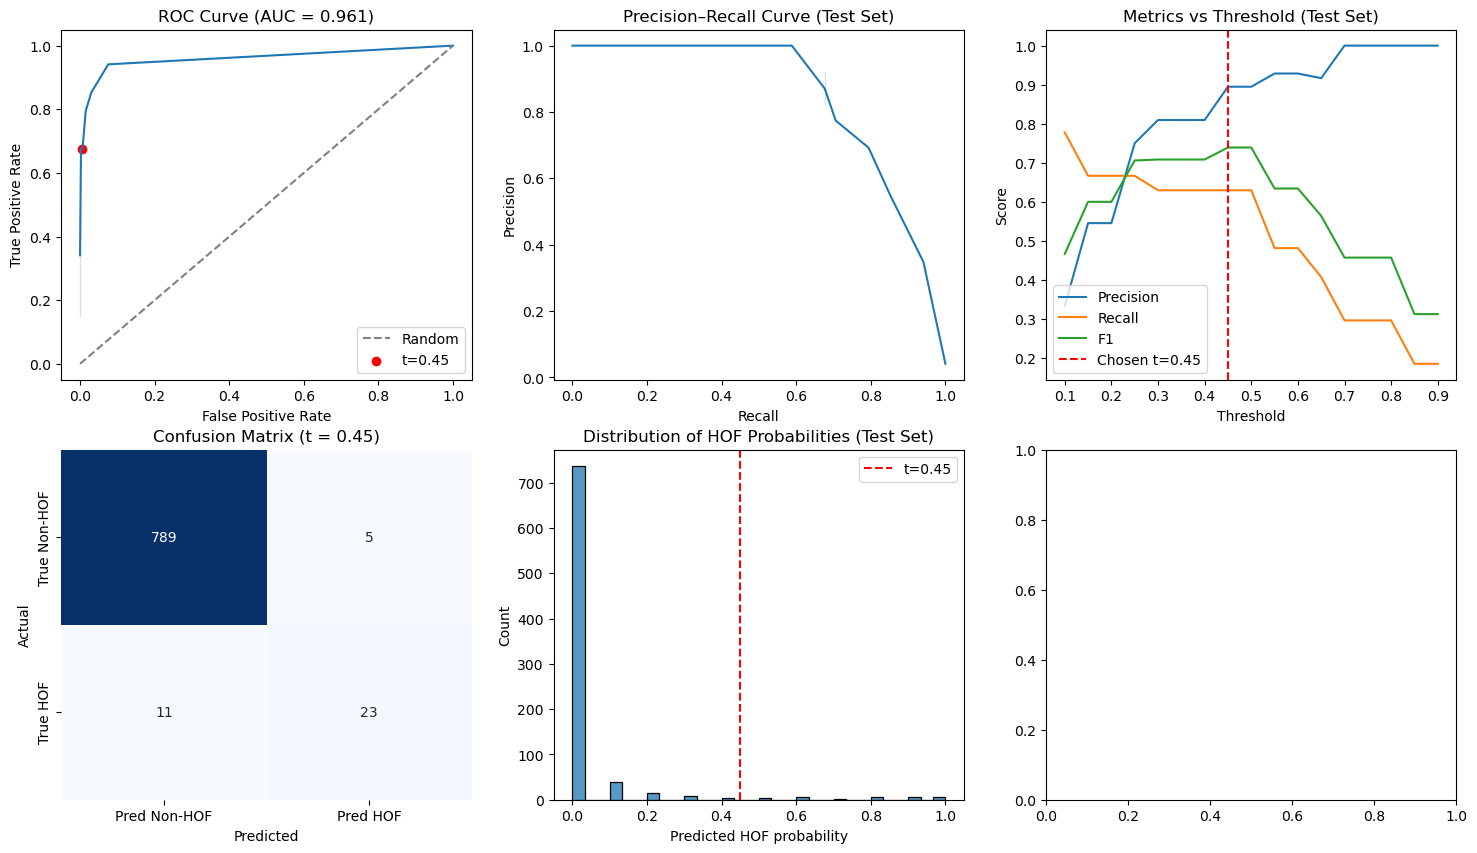

In [197]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ax_roc, ax_pr, ax_thr, ax_cm, ax_hist, ax_feat = axes.flatten()

# 1. roc curve
sns.lineplot(x=fpr, y=tpr, ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], "--", color="gray", label="Random")
# mark chosen threshold on ROC (closest point)
idx_best = np.argmin(np.abs(roc_thr - best_t))
ax_roc.scatter(fpr[idx_best], tpr[idx_best], color="red", label=f"t={best_t:.2f}")
ax_roc.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

# 2. precision recall curve
sns.lineplot(x=rec_curve, y=prec_curve, ax=ax_pr)
ax_pr.set_title("Precision–Recall Curve (Test Set)")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")

# 3. precision, recall, f1
sns.lineplot(
    data=threshold_df,
    x="threshold",
    y="precision",
    label="Precision",
    ax=ax_thr
)
sns.lineplot(
    data=threshold_df,
    x="threshold",
    y="recall",
    label="Recall",
    ax=ax_thr
)
sns.lineplot(
    data=threshold_df,
    x="threshold",
    y="f1",
    label="F1",
    ax=ax_thr
)
ax_thr.axvline(best_t, color="red", linestyle="--", label=f"Chosen t={best_t:.2f}")
ax_thr.set_title("Metrics vs Threshold (Test Set)")
ax_thr.set_xlabel("Threshold")
ax_thr.set_ylabel("Score")
ax_thr.legend()

# 4. confusion matrix for predicted values
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax_cm
)
ax_cm.set_title(f"Confusion Matrix (t = {best_t:.2f})")
ax_cm.set_xlabel("Predicted")
ax_cm.set_ylabel("Actual")

# 5 histogram possible hof
sns.histplot(y_proba_test, bins=30, kde=False, ax=ax_hist)
ax_hist.axvline(best_t, color="red", linestyle="--", label=f"t={best_t:.2f}")
ax_hist.set_title("Distribution of HOF Probabilities (Test Set)")
ax_hist.set_xlabel("Predicted HOF probability")
ax_hist.set_ylabel("Count")
ax_hist.legend()

# 6. feature importance bar chart
importancedf = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm.importances_mean
}).sort_values("importance_mean", ascending=False).head(10)

sns.barplot(
    data=importancedf,
    x="importance_mean",
    y="feature",
    ax=ax_feat,
    orient="h"
)
ax_feat.set_title("Top 10 Feature Importances")
ax_feat.set_xlabel("Importance (permutation)")
ax_feat.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
tuned_model.score(X_test, y_test)

In [423]:
pred_hof('Michael Jordan')

Michael Jordan is predicted to be a Hall-of-Famer with a probability of 0.9921875
